# Анализ туристической индустрии России

**Описание проекта**

В проекте анализируются данные агрегатора отелей и туристических фирм по субъектам Российской Федерации за 2018–2023 годы.

Исследование направлено на изучение туристической инфраструктуры, спроса на размещение в гостиницах и динамики продаж турпакетов. Особое внимание уделено внутреннему туризму, стоимости реализованных турпакетов и региональным различиям.

Результаты анализа могут быть полезны сервису для персонализации туристических маршрутов, оценки перспективных регионов и разработки маркетинговых стратегий.

**Цель проекта**

На основе данных агрегатора отелей изучить состояние туристической индустрии России, выявить региональные особенности и проверить гипотезы о стоимости и динамике продаж турпакетов.

В рамках проекта необходимо:

1. Подготовить данные к анализу: проверить пропуски, типы данных и некорректные значения.
2. Изучить распределение гостиниц, хостелов и санаторно-курортных организаций по регионам.
3. Определить регионы с наибольшей стоимостью реализованных турпакетов в 2023 году.
4. Проанализировать динамику среднего количества турпакетов за 2018–2023 годы.
5. Проверить статистические гипотезы о стоимости турпакетов и росте внутреннего туризма.


## Описание данных

Данные представлены несколькими таблицами:

- Таблица с числом гостиниц, хостелов, санаторно-курортных организаций и мест в них по субъектам Российской Федерации за 2018–2023 годы
- Таблица  с количеством людей, размещённых в гостиницах по субъектам Российской Федерации в 2023 году
- Таблица с числом реализованных турпакетов в 2018-2023 годы
- Таблица с основными показателями деятельности туристических фирм по субъектам Российской Федерации в 2023 году


## Выполнение проекта
### Шаг 1. Загрузка данных
Загружаем все необходимые данные и знакомимся с содержанием таблиц.

#### Импорт библиотек
Импортируем необходимые для работы библиотеки

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np

#### Чтение данных
Cчитываем и сохраняем данные в отдельные датафреймы.

In [2]:
df_hotel = pd.read_csv('hotel.csv', sep=';')
df_person_hotel = pd.read_csv('count_person_hotel.csv', sep=';')
df_tour_firm = pd.read_csv('tour_firm.csv', sep=';')
df_tour_cost_2023 = pd.read_csv('tour_cost_2023.csv', sep=';')

### Шаг 2. Предобработка данных

Выводим названия столбцов для проверки

In [3]:
df_hotel.columns

Index(['Субъект', 'Число гостиниц, 2018', 'Число гостиниц, 2019',
       'Число гостиниц, 2020', 'Число гостиниц, 2021', 'Число гостиниц, 2022',
       'Число гостиниц, 2023', 'Число мест в гостиницах, 2018',
       'Число мест в гостиницах, 2019', 'Число мест в гостиницах, 2020',
       'Число мест в гостиницах, 2021', 'Число мест в гостиницах, 2022',
       'Число мест в гостиницах, 2023', 'Число хостелов, 2018',
       'Число хостелов, 2019', 'Число хостелов, 2020', 'Число хостелов, 2021',
       'Число хостелов, 2022', 'Число хостелов, 2023',
       'Число мест в хостелах, 2018', 'Число мест в хостелах, 2019',
       'Число мест в хостелах, 2020', 'Число мест в хостелах, 2021',
       'Число мест в хостелах, 2022', 'Число мест в хостелах, 2023',
       'Число санаторно-курортных организаций, 2018',
       'Число санаторно-курортных организаций, 2019',
       'Число санаторно-курортных организаций, 2020',
       'Число санаторно-курортных организаций, 2021',
       'Число санаторно-

In [4]:
df_person_hotel.columns

Index(['Субъект', 'Численность лиц, размещенных в гостиницах в 2023 году',
       'Численность граждан России, размещенных в гостиницах в 2023 году',
       'Численность иностранных граждан, размещенных в гостиницах в 2023 году'],
      dtype='object')

In [5]:
df_tour_firm.columns

Index(['Субъект', 'Общее число турпакетов, реализованных населению, 2018',
       'Общее число турпакетов, реализованных гражданам России по территории России, 2018',
       'Общее число турпакетов, реализованных гражданам России по другим странам, 2018',
       'Общее число турпакетов, реализованных гражданам других стран по территории России, 2018',
       'Общее число турпакетов, реализованных населению, 2019',
       'Общее число турпакетов, реализованных гражданам России по территории России, 2019',
       'Общее число турпакетов, реализованных гражданам России по другим странам, 2019',
       'Общее число турпакетов, реализованных гражданам других стран по территории России, 2019',
       'Общее число турпакетов, реализованных населению, 2020',
       'Общее число турпакетов, реализованных гражданам России по территории России, 2020',
       'Общее число турпакетов, реализованных гражданам России по другим странам, 2020',
       'Общее число турпакетов, реализованных гражданам др

In [6]:
df_tour_cost_2023.columns

Index(['Субъект', 'Стоимость реализованных турпакетов в 2023 году, млн руб.',
       'Стоимость турпакетов  реализованных гражданам России по территории России в 2023 году, млн руб.',
       'Стоимость турпакетов  реализованных гражданам России по другим странам в 2023 году, млн руб.'],
      dtype='object')

Доработаем названия столбцов для удобства, уберем лишние пробелы и символы, которые могут вызывать ошибки при обработке. Кроме того, заменим некоторые названия на короткие и понятные имена вместо длинных и сложных названий.

#### Переименование столбцов

Значениям столбцов присвоим новые имена.

In [7]:
column_names_hotel = [
    "region", "hotels_2018", "hotels_2019", "hotels_2020", "hotels_2021",
    "hotels_2022", "hotels_2023", "beds_hotels_2018", "beds_hotels_2019",
    "beds_hotels_2020", "beds_hotels_2021", "beds_hotels_2022", "beds_hotels_2023",
    "hostels_2018", "hostels_2019", "hostels_2020", "hostels_2021", "hostels_2022", "hostels_2023",
    "beds_hostels_2018", "beds_hostels_2019", "beds_hostels_2020", "beds_hostels_2021", "beds_hostels_2022",
    "beds_hostels_2023", "spa_orgs_2018", "spa_orgs_2019", "spa_orgs_2020", "spa_orgs_2021", "spa_orgs_2022", "spa_orgs_2023",
    "beds_spa_2018", "beds_spa_2019", "beds_spa_2020", "beds_spa_2021", "beds_spa_2022", "beds_spa_2023"
]

In [8]:
df_hotel.columns = column_names_hotel

In [9]:
df_hotel.columns

Index(['region', 'hotels_2018', 'hotels_2019', 'hotels_2020', 'hotels_2021',
       'hotels_2022', 'hotels_2023', 'beds_hotels_2018', 'beds_hotels_2019',
       'beds_hotels_2020', 'beds_hotels_2021', 'beds_hotels_2022',
       'beds_hotels_2023', 'hostels_2018', 'hostels_2019', 'hostels_2020',
       'hostels_2021', 'hostels_2022', 'hostels_2023', 'beds_hostels_2018',
       'beds_hostels_2019', 'beds_hostels_2020', 'beds_hostels_2021',
       'beds_hostels_2022', 'beds_hostels_2023', 'spa_orgs_2018',
       'spa_orgs_2019', 'spa_orgs_2020', 'spa_orgs_2021', 'spa_orgs_2022',
       'spa_orgs_2023', 'beds_spa_2018', 'beds_spa_2019', 'beds_spa_2020',
       'beds_spa_2021', 'beds_spa_2022', 'beds_spa_2023'],
      dtype='object')

In [10]:
column_person_hotel = [
    "region",
    "total_guests_2023",
    "russian_guests_2023",
    "foreign_guests_2023"
]

In [11]:
df_person_hotel.columns = column_person_hotel

In [12]:
column_tour_firm = [
    "region",
    "total_tour_packages_2018", "domestic_russia_2018", "international_russia_2018", "foreign_in_russia_2018",
    "total_tour_packages_2019", "domestic_russia_2019", "international_russia_2019", "foreign_in_russia_2019",
    "total_tour_packages_2020", "domestic_russia_2020", "international_russia_2020", "foreign_in_russia_2020",
    "total_tour_packages_2021", "domestic_russia_2021", "international_russia_2021", "foreign_in_russia_2021",
    "total_tour_packages_2022", "domestic_russia_2022", "international_russia_2022", "foreign_in_russia_2022",
    "total_tour_packages_2023", "domestic_russia_2023", "international_russia_2023", "foreign_in_russia_2023"
]

In [13]:
df_tour_firm.columns = column_tour_firm

In [14]:
column_tour_cost_2023  = [
    "region",
    "total_tour_cost_million_2023",
    "domestic_tour_package_cost_million_2023",
    "international_tour_package_cost_million_2023"
]

In [15]:
df_tour_cost_2023.columns = column_tour_cost_2023

####  Анализ типов данных, пропусков, замена некорректных значений

Проанализируем типы данных в колонках

##### Анализ типов данных

Выводим типы данных всех колонок.

In [16]:
df_hotel.dtypes

region               object
hotels_2018           int64
hotels_2019           int64
hotels_2020           int64
hotels_2021           int64
hotels_2022           int64
hotels_2023           int64
beds_hotels_2018      int64
beds_hotels_2019      int64
beds_hotels_2020      int64
beds_hotels_2021      int64
beds_hotels_2022      int64
beds_hotels_2023      int64
hostels_2018          int64
hostels_2019          int64
hostels_2020          int64
hostels_2021          int64
hostels_2022          int64
hostels_2023          int64
beds_hostels_2018    object
beds_hostels_2019    object
beds_hostels_2020    object
beds_hostels_2021    object
beds_hostels_2022    object
beds_hostels_2023    object
spa_orgs_2018         int64
spa_orgs_2019         int64
spa_orgs_2020         int64
spa_orgs_2021         int64
spa_orgs_2022         int64
spa_orgs_2023         int64
beds_spa_2018        object
beds_spa_2019        object
beds_spa_2020        object
beds_spa_2021        object
beds_spa_2022       

Число мест в хостелах и санаторно-курортных организациях имеет тип данных `object`. Это столбцы `beds_hotels` и `beds_spa` за разные годы. Нужно привести их к числовому формату.

In [17]:
df_person_hotel.dtypes

region                 object
total_guests_2023       int64
russian_guests_2023     int64
foreign_guests_2023     int64
dtype: object

Здесь всё в порядке — каждый столбец имеет соответствующий формат.

In [18]:
df_tour_firm.dtypes

region                        object
total_tour_packages_2018      object
domestic_russia_2018          object
international_russia_2018     object
foreign_in_russia_2018       float64
total_tour_packages_2019      object
domestic_russia_2019          object
international_russia_2019     object
foreign_in_russia_2019        object
total_tour_packages_2020      object
domestic_russia_2020          object
international_russia_2020     object
foreign_in_russia_2020       float64
total_tour_packages_2021      object
domestic_russia_2021          object
international_russia_2021    float64
foreign_in_russia_2021        object
total_tour_packages_2022      object
domestic_russia_2022          object
international_russia_2022     object
foreign_in_russia_2022       float64
total_tour_packages_2023      object
domestic_russia_2023          object
international_russia_2023    float64
foreign_in_russia_2023       float64
dtype: object

В таблице `tour_firm.csv` с числом турпакетов, реализованных в 2018–2023 годы, есть ошибки в данных. Следует провести дополнительные проверки для дальнейших преобразований.

In [19]:
df_tour_cost_2023.dtypes

region                                          object
total_tour_cost_million_2023                    object
domestic_tour_package_cost_million_2023         object
international_tour_package_cost_million_2023    object
dtype: object

##### Изучаем пропуски

Данные часто содержат пропуски (`NaN`), что может мешать анализу. Проверим количество пропущенных значений в каждом датафрейме, отсортируем столбцы по числу убывания пропусков и отфильтруем ненулевые значения.

In [20]:
df_hotel.isnull().sum()

region               0
hotels_2018          0
hotels_2019          0
hotels_2020          0
hotels_2021          0
hotels_2022          0
hotels_2023          0
beds_hotels_2018     0
beds_hotels_2019     0
beds_hotels_2020     0
beds_hotels_2021     0
beds_hotels_2022     0
beds_hotels_2023     0
hostels_2018         0
hostels_2019         0
hostels_2020         0
hostels_2021         0
hostels_2022         0
hostels_2023         0
beds_hostels_2018    0
beds_hostels_2019    0
beds_hostels_2020    0
beds_hostels_2021    0
beds_hostels_2022    0
beds_hostels_2023    0
spa_orgs_2018        0
spa_orgs_2019        0
spa_orgs_2020        0
spa_orgs_2021        0
spa_orgs_2022        0
spa_orgs_2023        0
beds_spa_2018        0
beds_spa_2019        0
beds_spa_2020        0
beds_spa_2021        0
beds_spa_2022        0
beds_spa_2023        0
dtype: int64

In [21]:
df_person_hotel.isnull().sum()

region                 0
total_guests_2023      0
russian_guests_2023    0
foreign_guests_2023    0
dtype: int64

In [22]:
df_tour_firm.isnull().sum()

region                        0
total_tour_packages_2018      0
domestic_russia_2018          0
international_russia_2018     1
foreign_in_russia_2018       20
total_tour_packages_2019      0
domestic_russia_2019          0
international_russia_2019     0
foreign_in_russia_2019       19
total_tour_packages_2020      0
domestic_russia_2020          0
international_russia_2020     0
foreign_in_russia_2020       39
total_tour_packages_2021      1
domestic_russia_2021          1
international_russia_2021     2
foreign_in_russia_2021       37
total_tour_packages_2022      0
domestic_russia_2022          0
international_russia_2022     1
foreign_in_russia_2022       40
total_tour_packages_2023      0
domestic_russia_2023          0
international_russia_2023     1
foreign_in_russia_2023       39
dtype: int64

In [23]:
df_tour_firm.isnull().sum().sort_values(ascending = False)

foreign_in_russia_2022       40
foreign_in_russia_2020       39
foreign_in_russia_2023       39
foreign_in_russia_2021       37
foreign_in_russia_2018       20
foreign_in_russia_2019       19
international_russia_2021     2
international_russia_2018     1
total_tour_packages_2021      1
international_russia_2023     1
international_russia_2022     1
domestic_russia_2021          1
total_tour_packages_2018      0
international_russia_2020     0
domestic_russia_2020          0
total_tour_packages_2020      0
international_russia_2019     0
total_tour_packages_2022      0
domestic_russia_2022          0
domestic_russia_2019          0
domestic_russia_2018          0
total_tour_packages_2023      0
domestic_russia_2023          0
total_tour_packages_2019      0
region                        0
dtype: int64

In [24]:
df_tour_cost_2023.isnull().sum()

region                                          0
total_tour_cost_million_2023                    0
domestic_tour_package_cost_million_2023         0
international_tour_package_cost_million_2023    0
dtype: int64

В таблице `df_tour_firm` больше всего пропусков. Рассмотрим ее подробнее

Проверим пропуски и определим их долю. Для этого разделим количество пропусков на общее число строк.

In [25]:
df_hotel_info = pd.DataFrame({
    "DataType": df_hotel.dtypes,
    "MissingValues": df_hotel.isnull().sum(),
    "UniqueValues": df_hotel.nunique()
}).sort_values(by="MissingValues", ascending=False)

df_hotel_info['MissingValuesRatio'] = round(df_hotel_info['MissingValues'] / len(df_hotel),2)

In [26]:
df_person_hotel_info = pd.DataFrame({
    "DataType": df_person_hotel.dtypes,
    "MissingValues": df_person_hotel.isnull().sum(),
    "UniqueValues": df_person_hotel.nunique()
}).sort_values(by="MissingValues", ascending=False)

df_person_hotel_info['MissingValuesRatio'] = round(df_person_hotel_info['MissingValues'] / len(df_person_hotel),2)

In [27]:
df_tour_firm_info = pd.DataFrame({
    "DataType": df_tour_firm.dtypes,
    "MissingValues": df_tour_firm.isnull().sum(),
    "UniqueValues": df_tour_firm.nunique()
}).sort_values(by="MissingValues", ascending=False)

df_tour_firm_info['MissingValuesRatio'] = round(df_tour_firm_info['MissingValues'] / len(df_tour_firm),2)

In [28]:
df_tour_cost_2023_info = pd.DataFrame({
    "DataType": df_tour_cost_2023.dtypes,
    "MissingValues": df_tour_cost_2023.isnull().sum(),
    "UniqueValues": df_tour_cost_2023.nunique()
}).sort_values(by="MissingValues", ascending=False)

df_tour_cost_2023_info['MissingValuesRatio'] = round(df_tour_cost_2023_info['MissingValues'] / len(df_tour_cost_2023),2)

Изучим, почему в таблице `df_hotel` значения в колонках `beds_hostels` и `beds_spa` имеют строковый тип данных.

In [29]:
df_hotel['beds_hostels_2018'].unique()

array(['192', '0', '954', '1257', '184', '432', '356', '…1', '350',
       '5822', '352', '226', '491', '341', '428', '94749', '284', '163',
       '195', '1398', '1059', '675', '814', '439', '221', '8833', '1144',
       '6291', '136', '1494', '1183', '151', '375', '648', '667', '741',
       '3815', '329', '206', '854', '173', '2731', '589', '1178', '1661',
       '150', '199', '2671', '1399', '483', '571', '1081', '597', '787',
       '806', '307', '466', '83', '134', '261', '662', '924', '106',
       '256'], dtype=object)

Изучим природу строкового типа данных в датафрейме `df_tour_firm`.

In [30]:
df_tour_firm['total_tour_packages_2018'].unique()

array(['14138', '9444', '23900', '14554', '17049', '39436', '7514',
       '10008', '9307', '90769', '9426', '19380', '8597', '4937', '42819',
       '17012', '45116', '1141105', '37138', '18465', '40073', '31355',
       '51653', '22829', '16721', '9953', '10481', '518939', '4333',
       '2065', '77505', '168092', '42277', '31754', '84987', '25080',
       '11186', '…1', '1184', '2729', '1613', '64739', '53395', '10091',
       '12395', '154525', '22639', '17574', '106450', '23960', '76840',
       '22309', '19361', '69299', '27151', '15904', '13303', '170713',
       '75831', '84379', '4812', '1267', '7216', '41144', '57406',
       '49507', '45303', '110277', '41171', '25874', '11872', '147269',
       '15890', '13494', '125105', '42175', '55028', '2832', '8455'],
      dtype=object)

Значение `'…1'` не позволяет интерпретировать данные как числа. Заменим `'…1'` на `0` во всех датафреймах.

In [31]:
df_hotel = df_hotel.replace("…1", 0)
df_tour_firm = df_tour_firm.replace("…1", 0)

Заменяем все пропущенные значения в таблице `df_tour_firm` на `0`.

In [32]:
df_tour_firm = df_tour_firm.fillna(0)

Тип данных в датафреймах `df_hostel`, `df_sanatorium`, `df_tour_firm`, `df_tour_cost_2023` заменим с `object` на `float` во всех столбцах, кроме `region`.

Затем приведем выбранные столбцы к числовому формату

In [33]:
dfs = [df_hotel, df_tour_firm, df_tour_cost_2023]

for df in dfs:

    cols_to_convert = df.select_dtypes(include=['object']).columns.difference(['region'])
    df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

Данные готовы к работе

### Шаг 3. Исследовательский анализ данных

#### Изучить распределение количества гостиниц, хостелов и санаторно-курортных организаций за 2018–2023 годы.


Для анализа построим график «ящик с усами»

Выбираем шесть столбцов из датафрейма `df_hotel`, которые содержат количество отелей по годам.

In [34]:
hotel_selected = df_hotel[['hotels_2018', 'hotels_2019', 'hotels_2020', 'hotels_2021', 'hotels_2022', 'hotels_2023']]

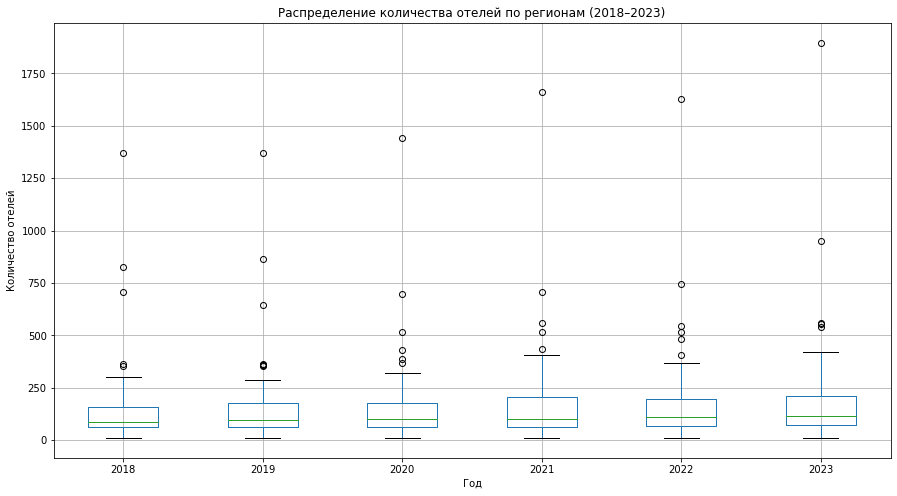

In [35]:
plt.figure(figsize=(15, 8))
hotel_selected.boxplot()
plt.title("Распределение количества отелей по регионам (2018–2023)")
plt.ylabel("Количество отелей")
plt.xlabel("Год")
plt.xticks(ticks=[1, 2, 3, 4, 5, 6], labels=["2018", "2019", "2020", "2021", "2022", "2023"])
plt.show()

* Верхний «ус» (граница без учёта выбросов) постепенно увеличивается к 2023 году, что говорит о том, что в некоторых регионах число отелей стало выше.
* Медиана (центральная линия) практически неизменна во все годы. Замечается незначительный медленный рост.

Аналогичным образом построим график для хостелов.

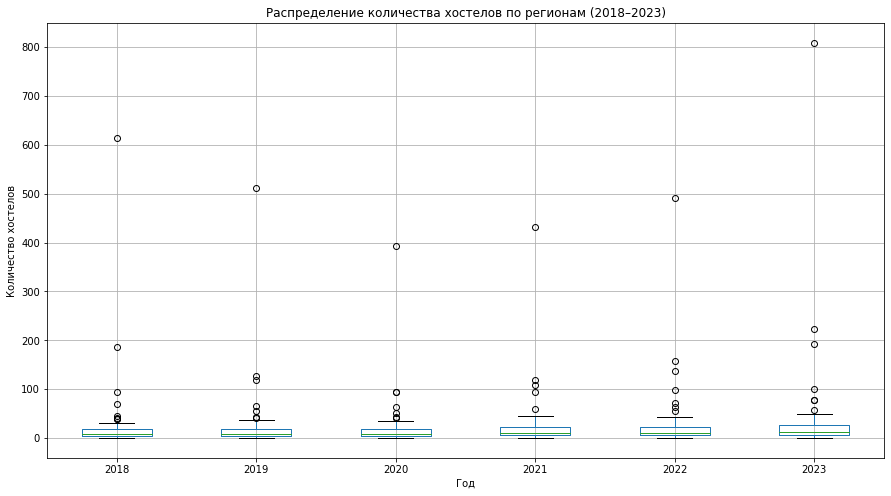

In [36]:
hostel_selected = df_hotel[['hostels_2018', 'hostels_2019', 'hostels_2020','hostels_2021', 'hostels_2022', 'hostels_2023']]
plt.figure(figsize=(15, 8))
hostel_selected.boxplot()
plt.title("Распределение количества хостелов по регионам (2018–2023)")
plt.ylabel("Количество хостелов")
plt.xlabel("Год")
plt.xticks(ticks=[1, 2, 3, 4, 5, 6], labels=["2018", "2019", "2020", "2021", "2022", "2023"])
plt.show()

* Некоторые регионы демонстрируют резкий рост числа хостелов, особенно в 2023 году.
* В 2022–2023 годы отмечается расширение рынка хостелов в отдельных туристических центрах.

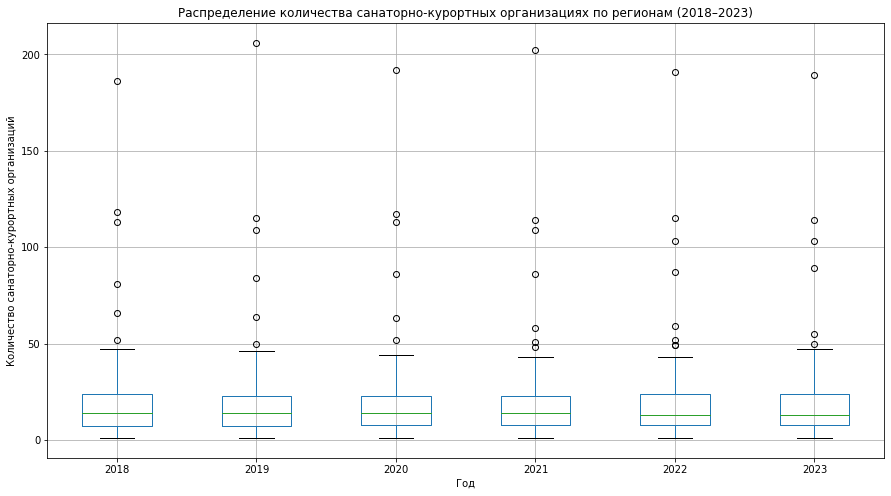

In [37]:
spa_selected = df_hotel[['spa_orgs_2018', 'spa_orgs_2019', 'spa_orgs_2020', 'spa_orgs_2021', 'spa_orgs_2022',
                        'spa_orgs_2023']]

plt.figure(figsize=(15, 8))
spa_selected.boxplot()
plt.title("Распределение количества санаторно-курортных организациях по регионам (2018–2023)")
plt.ylabel("Количество санаторно-курортных организаций")
plt.xlabel("Год")
plt.xticks(ticks=[1, 2, 3, 4, 5, 6], labels=["2018", "2019", "2020", "2021", "2022", "2023"])
plt.show()

* В каждом году встречаются выбросы (отдельные точки выше «усов»), что говорит о наличии регионов с аномально высоким числом санаторно-курортных организаций.
* В некоторых регионах более 100–200 санаториев, в то время как у большинства этот показатель ниже 50.

#### Определить топ-10 регионов России с наибольшей стоимостью турпакетов в 2023 году.
Построим горизонтальную столбчатую диаграмму:
* Ось X — стоимость турпакетов в миллионах рублей.
* Ось Y — регионы.

Сортируем датафрейм по колонке `total_tour_cost_million_2023` (стоимость турпакетов в миллионах рублей).
С помощью аргумента `ascending=False` сортируем по убыванию, то есть регионы, в которых купили больше всего турпакетов, будут указаны первыми.

In [38]:
top_regions = df_tour_cost_2023.sort_values(by="total_tour_cost_million_2023", ascending=False).head(10)

Строим горизонтальную столбчатую диаграмму.

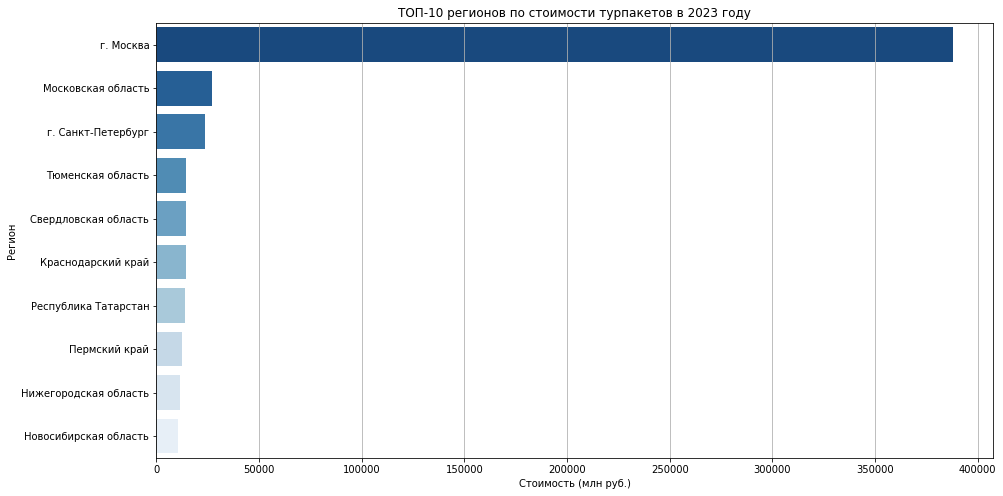

In [39]:
plt.figure(figsize=(15, 8))
sns.barplot(data=top_regions, x="total_tour_cost_million_2023", y="region", palette="Blues_r")
plt.title("ТОП-10 регионов по стоимости турпакетов в 2023 году")
plt.xlabel("Стоимость (млн руб.)")
plt.ylabel("Регион")
plt.grid(axis='x')
plt.show()

В Москве проживает наибольшее число туристов, готовых покупать турпакеты. Разрыв между Москвой и остальными регионами колоссальный — её вклад в рынок туризма существенно выше.

#### Построить линейный график, который покажет изменения среднего количества турпакетов в России по категориям с 2018 по 2023 год.

Создадим словарь `average_values`, который будет хранить данные о среднем количестве проданных турпакетов по годам:

* `Year` — список лет с 2018 по 2023.
* `Total Packages` — среднее общее количество турпакетов.
* `Domestic Russia` — среднее количество туров внутри России.
* `International Russia` — среднее количество международных туров.
* `Foreign in Russia` — среднее количество туров, купленных иностранцами в России.


In [40]:
average_values = {
    'Year': ['2018', '2019', '2020', '2021', '2022', '2023'],
    'Total Packages': [
        df_tour_firm['total_tour_packages_2018'].mean(),
        df_tour_firm['total_tour_packages_2019'].mean(),
        df_tour_firm['total_tour_packages_2020'].mean(),
        df_tour_firm['total_tour_packages_2021'].mean(),
        df_tour_firm['total_tour_packages_2022'].mean(),
        df_tour_firm['total_tour_packages_2023'].mean(),
    ],
    'Domestic Russia': [
        df_tour_firm['domestic_russia_2018'].mean(),
        df_tour_firm['domestic_russia_2019'].mean(),
        df_tour_firm['domestic_russia_2020'].mean(),
        df_tour_firm['domestic_russia_2021'].mean(),
        df_tour_firm['domestic_russia_2022'].mean(),
        df_tour_firm['domestic_russia_2023'].mean(),
    ],
    'International Russia': [
        df_tour_firm['international_russia_2018'].mean(),
        df_tour_firm['international_russia_2019'].mean(),
        df_tour_firm['international_russia_2020'].mean(),
        df_tour_firm['international_russia_2021'].mean(),
        df_tour_firm['international_russia_2022'].mean(),
        df_tour_firm['international_russia_2023'].mean(),
    ],
    'Foreign in Russia': [
        df_tour_firm['foreign_in_russia_2018'].mean(),
        df_tour_firm['foreign_in_russia_2019'].mean(),
        df_tour_firm['foreign_in_russia_2020'].mean(),
        df_tour_firm['foreign_in_russia_2021'].mean(),
        df_tour_firm['foreign_in_russia_2022'].mean(),
        df_tour_firm['foreign_in_russia_2023'].mean(),
    ]
}

Создадим датафрейм `df_avg` на основе словаря `average_values`, чтобы можно было проанализировать средние значения в табличном формате.

In [41]:
df_avg = pd.DataFrame(average_values)

Построим линейный график, показывающий изменения среднего количества турпакетов в России по категориям с 2018 по 2023 год.
Создадим график

* Ось X (Год) — значения от 2018 до 2023.
* Ось Y (Среднее число турпакетов) — количество туров, проданных в каждом году.

Добавим четыре линии на график, которые отображают:

* общее количество туров — сплошная линия (`marker=o`);
* внутренний туризм — пунктирная линия (`marker=s`);
* международные туры  — штрихпунктирная линия (`marker=^`);
* турпакеты, купленные иностранцами в России  — точечная линия (`marker=d`).


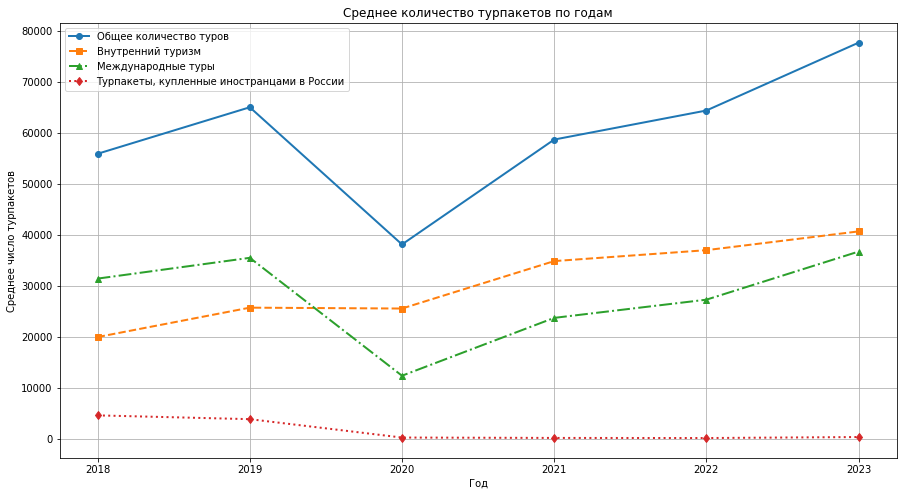

In [42]:
plt.figure(figsize=(15, 8))
plt.plot(df_avg['Year'], df_avg['Total Packages'], marker='o', label='Общее количество туров', linestyle='-', linewidth=2)
plt.plot(df_avg['Year'], df_avg['Domestic Russia'], marker='s', label='Внутренний туризм', linestyle='--', linewidth=2)
plt.plot(df_avg['Year'], df_avg['International Russia'], marker='^', label='Международные туры', linestyle='-.', linewidth=2)
plt.plot(df_avg['Year'], df_avg['Foreign in Russia'], marker='d', label='Турпакеты, купленные иностранцами в России', linestyle=':', linewidth=2)

plt.title('Среднее количество турпакетов по годам')
plt.xlabel('Год')
plt.ylabel('Среднее число турпакетов')
plt.legend()
plt.grid(True)
plt.show()


* Внутренний туризм продолжает расти и достигает пика в 2023 году.
* Международные туры восстановились, но всё ещё немного ниже 2019 года.

### Шаг 4. Проверка гипотез

#### Проверка гипотезы с одной выборкой

Туристическая индустрия является важной частью экономики, и анализ её показателей позволяет выявить тренды и оценить эффективность работы рынка. Один из ключевых показателей — средняя стоимость реализованных турпакетов.

Существует мнение, что средняя стоимость реализованных турпакетов в 2023 году составила 800 млн рублей. Однако аналитики подозревают, что этот показатель может быть больше. Задача — провести статистический тест, который поможет определить, можно ли отвергнуть нулевую гипотезу в пользу альтернативной.

Нужно проверить одностороннюю гипотезу:

* H0: Средняя стоимость реализованных турпакетов в 2023 году (млн рублей) = 800
* H1: Средняя стоимость реализованных турпакетов в 2023 году (млн рублей) > 800

Выберем из датафрейма `df_tour_cost_2023` столбец, содержащий данные о стоимости реализованных турпакетов в 2023 году.

In [43]:
total_tour_cost_2023 = df_tour_cost_2023['total_tour_cost_million_2023']

Установим параметры, которые будут использоваться в проверке статистической гипотезы:

* `expected_mean_tour_cost = 800` — это ожидаемое среднее значение стоимости реализованных турпакетов в 2023 году (в млн рублей), с которым будем сравнивать реальные данные.
* `alpha = 0.05` — это уровень статистической значимости (обычно 5%, или 0.05), который определяет границу для принятия или отклонения нулевой гипотезы.

In [44]:
expected_mean_tour_cost = 800
alpha = 0.05

Выполним t-тест с альтернативной гипотезой

In [45]:
results = st.ttest_1samp(
    total_tour_cost_2023,
    expected_mean_tour_cost,
    alternative='greater')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: nan
Не получилось отвергнуть нулевую гипотезу


Так как 0.049 < 0.01, то мы не можем отвергнуть нулевую гипотезу. Это означает, что средняя стоимость реализованных турпакетов в 2023 году c большой вероятностью превышает 800 млн рублей.

####  Проверка гипотезы с двумя выборками

Статистика говорит, что в 2023 году, по сравнению с 2022, россияне стали чаще ездить по стране и оформлять турпакеты. Проверим статистическую гипотезу о том, стало ли в 2023 году больше проданных турпакетов по России, чем в 2022 году.

Проверим одностороннюю гипотезу:

* H0: Среднее количество турпакетов, реализованных в 2022 году = Среднему количеству турпакетов, реализованных в 2023 году
* H1: Среднее количество турпакетов, реализованных в 2022 году < Cреднего количества турпакетов, реализованных в 2023 году

In [46]:
df_tour_firm['domestic_russia_2023'].mean()

40649.9756097561

In [47]:
domestic_russia_2022 = df_tour_firm['domestic_russia_2022']
domestic_russia_2023 = df_tour_firm['domestic_russia_2023']
alpha = 0.05

In [48]:
results = st.ttest_ind(
    domestic_russia_2022,
    domestic_russia_2023,
    alternative='less'
)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-значение: 0.43088448306931165
Не отвергаем нулевую гипотезу


* В нашем случае p-value = 0.431, что намного больше 0.05. Данные не подтверждают, что россияне стали больше путешествовать в 2023 году по сравнению с 2022 годом.
* Хотя среднее количество туров в 2023 году выше (40650), разница недостаточно значима с точки зрения статистики. Значение p-value = 0.431 говорит о высокой вероятности того, что наблюдаемые различия могли возникнуть случайно.